# **<center>CNN si YOLO pentru clasificarea si detectarea obiectelor<center>**
## <ins>Overview<ins>

 **1. Incarcam librariile necesare si definim dataset-ul.**

 **2. Construim o retea CNN personalizata in PyTorch pentru clasificarea imaginilor.**

 **3. Definim procesul de antrenare si validare cu monitorizarea metricilor.**

 **4. Salvam modelul si afisam grafice cu accuracy si loss.**

 **5. Validam modelul prin vizualizarea predictiilor pe imagini.**

 **6. Incarcam YOLO pentru detectia obiectelor pe datasetul MAR20.**

## <center>1: Setup - importuri si definirea dataset-ului<center>

Incarcam imaginile, le procesam si apoi lucram cu perechi de tipul (imagine, label)

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms


DATASET_DIR = "/kaggle/input/aircraft-dataset"
ROOT_PATH = DATASET_DIR + "/"
RESIZE_VALUE = 130

In [ ]:
# Extragerea claselor obiectelor 
types_path = ROOT_PATH + "TYPE-NAMES.txt"
aircraft_types = []
with open(types_path, "r") as f:
    for t in f.read().split():
        aircraft_types.append(t.replace('"',''))

NUM_CLASSES = len(aircraft_types)
# print("Classes:", NUM_CLASSES, aircraft_types)

# Transformarea dataset-ului la unul compatibil cu pytorch
class AircraftDataset(Dataset):
    def __init__(self, root, aircraft_types, transform=None):
        self.data = []
        self.transform = transform
        for idx, atype in enumerate(aircraft_types):
            path = os.path.join(root, atype)
            for fname in os.listdir(path):
                try:
                    img = Image.open(os.path.join(path, fname)).convert("RGB")
                    self.data.append((img, idx))
                except:
                    pass

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, label = self.data[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

## <center>2: Definirea arhitecturii CNN<center>
Arhitectura are 2 componente principale:

    Layer de feature extraction:

        Convolutional layer (3 -> 32 filtre, kernel 3x3), ReLU, MaxPooling 2x2

        Convolutional layer (32 -> 64 filtre, kernel 3x3), ReLU, MaxPooling 2x2

        Convolutional layer (64 -> 32 filtre, kernel 3x3), ReLU, MaxPooling 2x2

    Layer de clasificare:

        Flatten

        Fully connected cu 450 neuroni, activare ReLU

        Dropout 0.65 pentru regularizare

        Fully connected catre num_classes

In [ ]:
# Construirea retelei neurale cu 3 hidden layers
class CNNAircraft(nn.Module):
    def __init__(self, num_classes):
        super(CNNAircraft, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 450),  # TODO: de adjustat valoarea 14*14
            nn.ReLU(),
            nn.Dropout(0.65),
            nn.Linear(450, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## <center>3: Preprocesare, split si DataLoader<center>

Aplicam transformari: redimensionare la 130x130 pixeli, flip orizontal aleator, conversie in tensor.

Impartim datasetul in train-val 70-30.
Folosim DataLoader pentru a incarca batch-uri de 64 imagini, cu shuffle pe train.

In [ ]:
# Augmentari pentru train
train_transform = transforms.Compose([
    transforms.Resize((RESIZE_VALUE, RESIZE_VALUE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),  # converts to [0,1]
])

# Incarcarea dataset-ului si train-test split 70-30
dataset = AircraftDataset(ROOT_PATH, aircraft_types, transform=train_transform)
train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

## <center>4: Optimizator, loss function si setup GPU<center>

In [ ]:
# Incarcarea modelului pe gpu si setarea loss-ului si optimizer-ului pt backprop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNAircraft(NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

## <center>5: Antrenarea si validarea modelului + grafice accuracy&loss<center>

Antrenam reteaua timp de 30 epoci.
In fiecare epoca:

    Train
        propagam inainte, calculam loss, backpropagation, update parametri.
        calculam accuracy si loss mediu.

    Validare:
        propagam inainte fara backpropagation.
        calculam accuracy si loss mediu.

Salvam istoricul pentru accuracy si loss atat pe train cat si pe validare.
Afisam metricile la fiecare epoca pentru a monitoriza evolutia.
Iar graficele arata daca modelul invata corect, daca apare overfitting ) sau daca learning rate-ul este corespunzator.

Epoch 1/30 - Train Loss: 0.8974 Acc: 81.58% | Val Loss: 0.7697 Acc: 81.42%
Epoch 2/30 - Train Loss: 0.6460 Acc: 83.69% | Val Loss: 0.5300 Acc: 85.25%
Epoch 3/30 - Train Loss: 0.5121 Acc: 85.84% | Val Loss: 0.4410 Acc: 86.48%
Epoch 4/30 - Train Loss: 0.4433 Acc: 87.23% | Val Loss: 0.3805 Acc: 89.09%
Epoch 5/30 - Train Loss: 0.3881 Acc: 88.63% | Val Loss: 0.3264 Acc: 90.22%
Epoch 6/30 - Train Loss: 0.3406 Acc: 90.24% | Val Loss: 0.2906 Acc: 91.26%
Epoch 7/30 - Train Loss: 0.3055 Acc: 91.23% | Val Loss: 0.2648 Acc: 92.28%
Epoch 8/30 - Train Loss: 0.2789 Acc: 91.83% | Val Loss: 0.2263 Acc: 93.28%
Epoch 9/30 - Train Loss: 0.2508 Acc: 92.67% | Val Loss: 0.2052 Acc: 93.61%
Epoch 10/30 - Train Loss: 0.2305 Acc: 93.34% | Val Loss: 0.1820 Acc: 94.54%
Epoch 11/30 - Train Loss: 0.2103 Acc: 93.89% | Val Loss: 0.1663 Acc: 95.02%
Epoch 12/30 - Train Loss: 0.1917 Acc: 94.37% | Val Loss: 0.1555 Acc: 95.17%
Epoch 13/30 - Train Loss: 0.1777 Acc: 94.85% | Val Loss: 0.1478 Acc: 95.35%
Epoch 14/30 - Train L

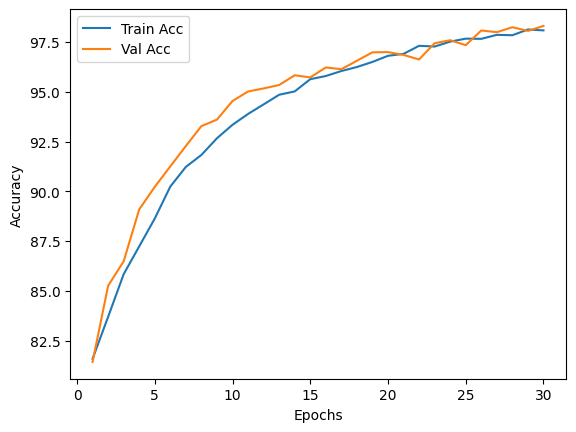

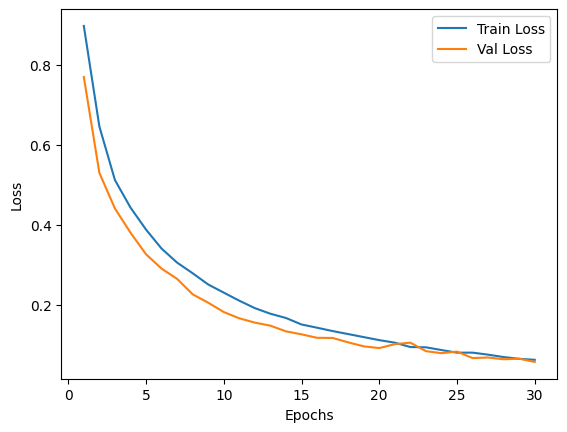

In [3]:
# Procesul de antrenare si validare
epochs = 30
# Istoric pt grafice
train_acc_history, val_acc_history = [], []
train_loss_history, val_loss_history = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        # Aplicam adam fara gradienti
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Calculam metricile
        running_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100 * correct / total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # Validare
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= total
    val_acc = 100 * correct / total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

# Graficele pentru accuracy si loss pe timpul antrenarii si validari
plt.figure()

plt.plot(range(1, epochs+1), train_acc_history, label="Train Acc")
plt.plot(range(1, epochs+1), val_acc_history, label="Val Acc")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

plt.figure()

plt.plot(range(1, epochs+1), train_loss_history, label="Train Loss")
plt.plot(range(1, epochs+1), val_loss_history, label="Val Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

# Salvarea modelului
torch.save(model.state_dict(), os.path.join("/kaggle/working/", "model_v1.pth"))


## <center>6: Validare CNN si vizualizare predictii<center>
Reincarcam modelul salvat si il punem in modul eval.
Definim o functie care afiseaza 5 imagini din fiecare clasa.
Pentru fiecare imagine afisam atat clasa reala (Target) cat si predictia modelului (Predicted).

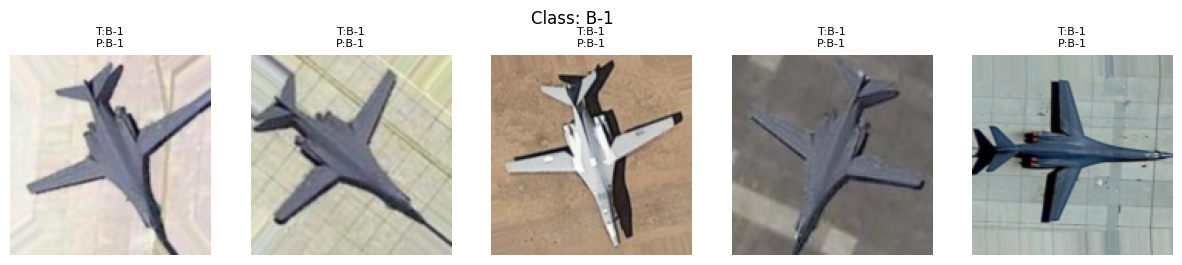

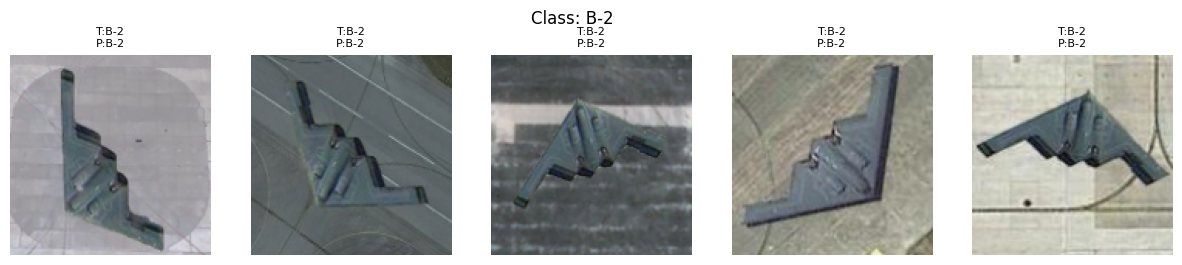

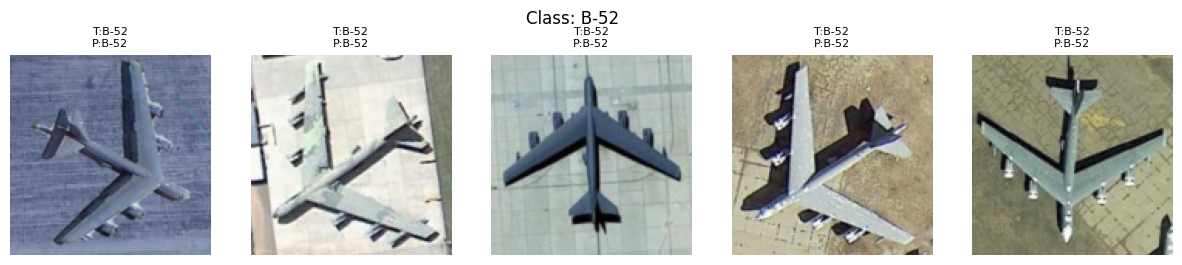

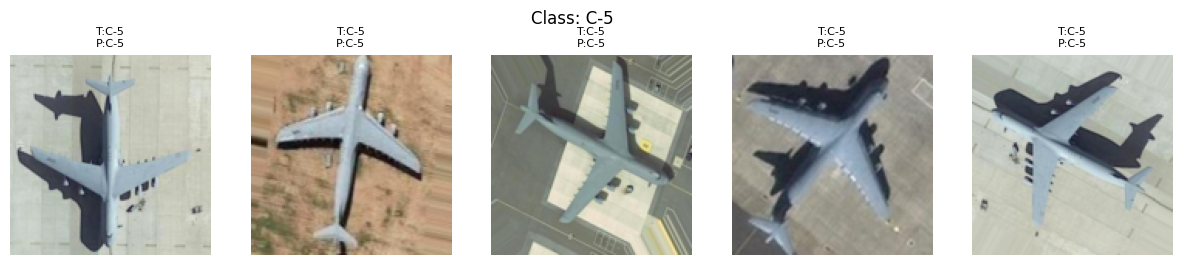

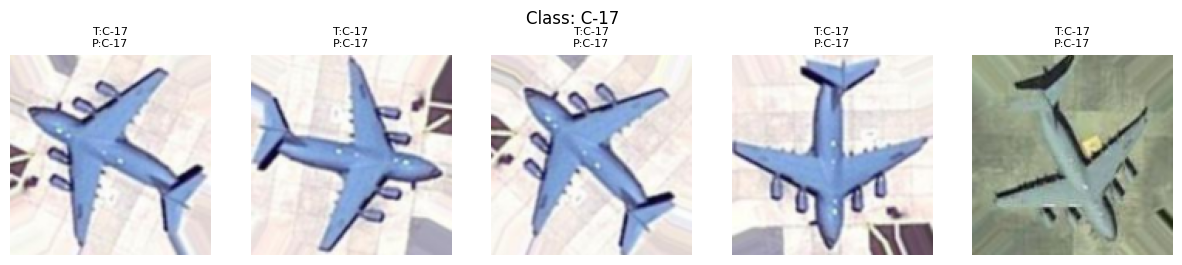

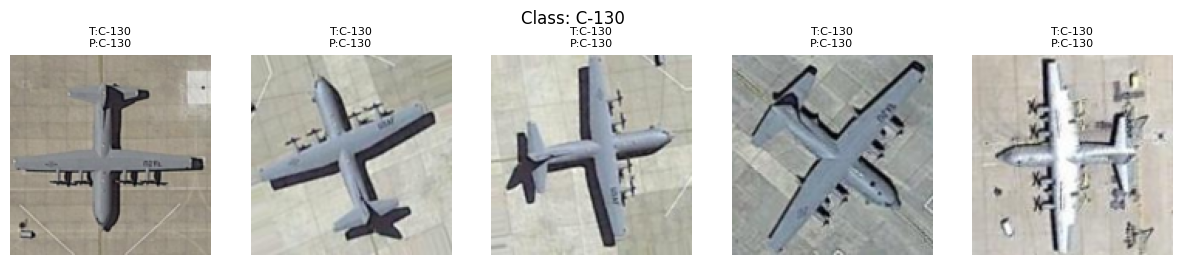

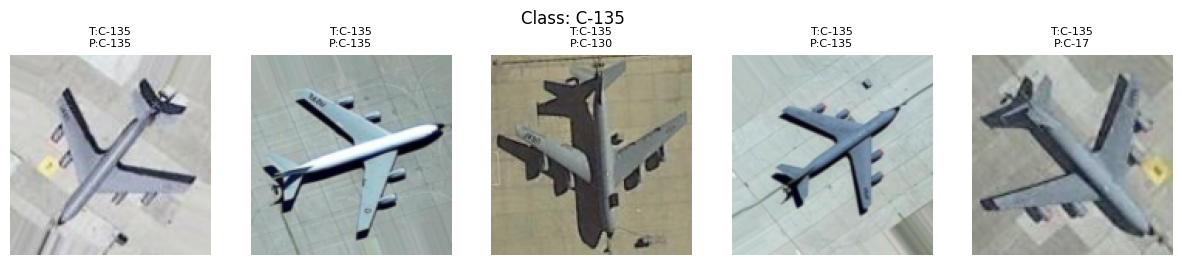

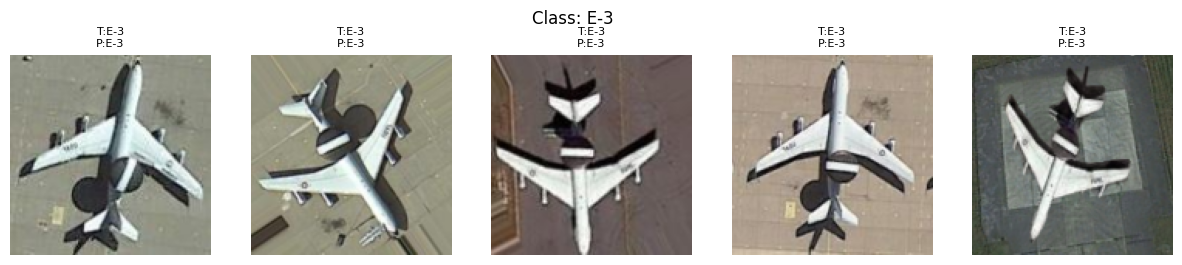

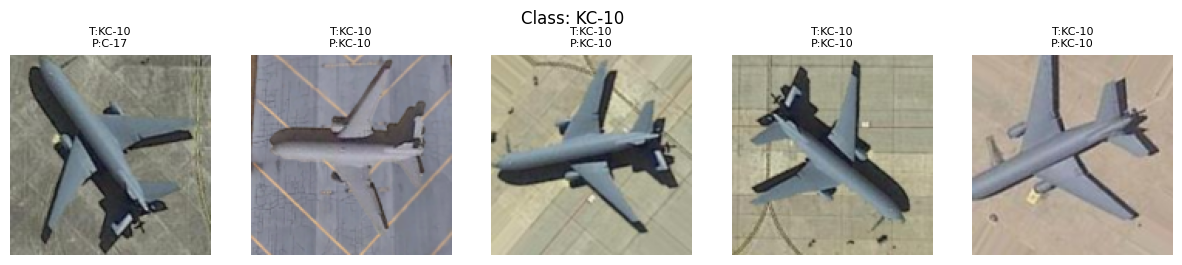

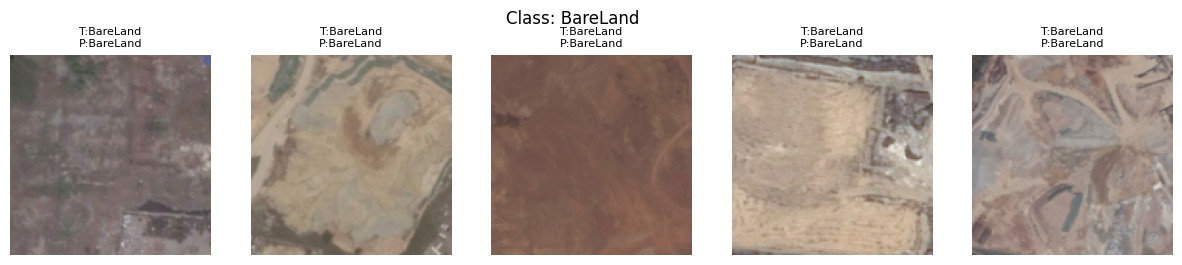

In [8]:
import torch
import matplotlib.pyplot as plt
import random

# Incarcare model salvat
model = CNNAircraft(NUM_CLASSES).to(device)
model.load_state_dict(torch.load("/kaggle/working/model_v1.pth", map_location=device))
model.eval()

# Functie pentru afisarea a 5 imagini din fiecare clasa
def show_predictions_per_class(model, dataset, aircraft_types, device, num_images=5):
    model.eval()
    for class_idx, class_name in enumerate(aircraft_types):
        # Gasim toate indicii din dataset pentru clasa curenta
        indices = [i for i, (_, label) in enumerate(dataset) if label == class_idx]
        if len(indices) == 0:
            continue

        # Alegem aleatoriu pana la num_images imagini
        chosen_indices = random.sample(indices, min(num_images, len(indices)))

        plt.figure(figsize=(15, 3))
        plt.suptitle(f"Class: {class_name}", fontsize=12)

        for j, idx in enumerate(chosen_indices):
            img, label = dataset[idx]
            input_img = img.unsqueeze(0).to(device)

            with torch.no_grad():
                outputs = model(input_img)
                _, predicted = outputs.max(1)

            plt.subplot(1, num_images, j + 1)
            plt.imshow(img.permute(1, 2, 0).cpu().numpy())
            plt.axis("off")
            plt.title(
                f"T:{aircraft_types[label]}\nP:{aircraft_types[predicted.item()]}",
                fontsize=8
            )

        plt.show()

# Afisam 5 imagini din fiecare clasa
show_predictions_per_class(model, val_dataset, aircraft_types, device, num_images=5)


# <center>YOLO pentru detectia obiectelor pe datasetul MAR20<center>

## <center>10: Setup si definirea path-urilor<center>

Aici definim path-urile catre imaginile datasetului (JPEGImages), adnotarile (Annotations), spliturile (ImageSets/Main) si directorul de lucru unde se vor genera fisierele pentru YOLO (mar20_yolo).

In [ ]:
import os, glob, shutil, xml.etree.ElementTree as ET
from pathlib import Path
from ultralytics import YOLO

In [ ]:
ROOT = Path("/kaggle/input/mar20-data")
IMAGES_DIR = ROOT / "JPEGImages"
ANNOT_ROOT = ROOT / "Annotations"
SPLIT_DIR = ROOT / "ImageSets" / "Main"
WORK = Path("/kaggle/working/mar20_yolo")
DATA_YAML = WORK / "mar20.yaml"
PRED_DIR = Path("/kaggle/working/predictions")

# Verific sa fie totul instalat
(
 (IMAGES_DIR.exists() and ANNOT_ROOT.exists() and SPLIT_DIR.exists())
 or
 (_ for _ in ()).throw(FileNotFoundError("Dataset folders not found at /kaggle/input/mar20-data"))
)

# Determin file cu annotari
xml_paths = [Path(p) for p in glob.glob(str(ANNOT_ROOT / "**" / "*.xml"), recursive=True)]
if not xml_paths:
    raise FileNotFoundError("No XML annotations found under annotations/")


## <center>11: Preprocesarea adnotarilor XML<center>
Adnotarile sunt in format Pascal VOC (XML). Aceste fisiere descriu bounding box-urile pentru obiectele din imagini.

Colectam toate fisierele XML.

Mapam fiecare imagine la fisierul sau XML corespunzator. Daca exista mai multe fisiere XML pentru aceeasi imagine, alegem varianta cea mai consistenta.

In [ ]:
# Verific daca este un bounding box orizontal
def is_hbb(xml_path):
    try:
        tree = ET.parse(xml_path); root = tree.getroot()
        return root.find(".//bndbox") is not None
    except:
        return False

# Mapam fiecare poza la fisierul sau xml cu adnotari
xml_by_id = {}
for xp in xml_paths:
    stem = xp.stem
    if stem.isdigit():
        if stem not in xml_by_id:
            xml_by_id[stem] = xp
        else:
            # Inlocuiesc vechiul xml cu cel gasit la pasul curent
            if is_hbb(xp) and not is_hbb(xml_by_id[stem]):
                xml_by_id[stem] = xp

## <center>12: Splitul train/test si extragerea claselor<center>

Citim id-urile pentru train si test din fisierele train.txt si test.txt.

Definim functia extract_classnames pentru a extrage toate numele de clase din fisierele XML.

In [ ]:
# Incarc datele de antrenament si de testare din filele cu id-uri
def read_ids(txt_path):
    with open(txt_path, "r", encoding="utf-8") as f:
        ids = [line.strip() for line in f if line.strip()]

    return [i for i in ids if i.isdigit()] # in caz de date corupte

train_ids = read_ids(SPLIT_DIR / "train.txt")
test_ids  = read_ids(SPLIT_DIR / "test.txt")

assert len(train_ids) > 0 and len(test_ids) > 0, "Empty train/test splits."

# Din annotari ne dam seama de clasele obiectelor si astfel le putem extrage
def extract_classnames(xml_path):
    try:
        root = ET.parse(xml_path).getroot()
        return [obj.findtext("name").strip() for obj in root.findall("object") if obj.findtext("name")]
    except:
        return []

classnames = set()
for i in set(train_ids + test_ids):
    xp = xml_by_id.get(i)
    if xp:
        classnames.update(extract_classnames(xp))
classnames = sorted(classnames)
cls2idx = {c: k for k, c in enumerate(classnames)}

## <center>13: Conversia adnotarilor la format YOLO<center>
YOLO necesita fisiere text care descriu bounding box-urile intr-un format specific:
clasa x_centru y_centru latime inaltime

In [ ]:
# Incadrarea lui v in [low, high]
def clamp(v, low, high):
    return max(low, min(high, v))

# yolo cere pentru fiecare imagine informatii despre bounding box-urile obiectelor gasite
# o linie este de forma <clasa> <x> <y> <w> <h>
def xml_to_yolo_lines(xml_path):
    root = ET.parse(xml_path).getroot()
    w = int(root.findtext("./size/width"))
    h = int(root.findtext("./size/height"))
    lines = []
    for obj in root.findall("object"):
        name = obj.findtext("name")
        if not name:
            continue

        cls = cls2idx.get(name.strip())
        if cls is None:
            continue

        box = obj.find("bndbox")
        if box is not None:
            xmin = float(box.findtext("xmin")); ymin = float(box.findtext("ymin"))
            xmax = float(box.findtext("xmax")); ymax = float(box.findtext("ymax"))
        else:
            rb = obj.find("robndbox")
            if rb is None:
                continue

            xs, ys = [], []
            for tag in ["x_left_top","y_left_top","x_right_top","y_right_top","x_right_bottom","y_right_bottom","x_left_bottom","y_left_bottom"]:
                val = rb.findtext(tag)

                if val is None:
                    xs, ys = [], []
                    break

                if tag.startswith("x_"):
                    xs.append(float(val))
                else:
                    ys.append(float(val))

            if not xs or not ys:
                continue

            xmin, xmax = min(xs), max(xs)
            ymin, ymax = min(ys), max(ys)

        xmin = clamp(xmin, 0, w - 1); xmax = clamp(xmax, 0, w - 1)
        ymin = clamp(ymin, 0, h - 1); ymax = clamp(ymax, 0, h - 1)

        bw = max(0.0, xmax - xmin); bh = max(0.0, ymax - ymin)
        if bw <= 1 or bh <= 1:
            continue

        xc = (xmin + xmax) / 2.0; yc = (ymin + ymax) / 2.0
        lines.append(f"{cls} {clamp(xc/w,0,1):.6f} {clamp(yc/h,0,1):.6f} {clamp(bw/w,0,1):.6f} {clamp(bh/h,0,1):.6f}")
    return lines

## <center>14: Crearea structurii YOLO dataset<center>

In [ ]:
# Cream noile foldere de lucru
for split in ["train", "test"]:
    (WORK / "images" / split).mkdir(parents=True, exist_ok=True)
    (WORK / "labels" / split).mkdir(parents=True, exist_ok=True)

# Folosind helperele construim efectiv labelele compatibile cu yolo
def process_split(ids, split):
    images_out = WORK / "images" / split
    labels_out = WORK / "labels" / split
    for i in ids:
        src_img = IMAGES_DIR / f"{i}.jpg"
        if not src_img.exists():
            continue

        dst_img = images_out / f"{i}.jpg"
        if dst_img.exists():
            dst_img.unlink()

        try:
            os.link(src_img, dst_img)
        except:
            shutil.copy2(src_img, dst_img)

        xp = xml_by_id.get(i)
        lines = xml_to_yolo_lines(xp) if xp else []
        with open(labels_out / f"{i}.txt", "w", encoding="utf-8") as f:
            f.write("\n".join(lines))

process_split(train_ids, "train")
process_split(test_ids, "test")

## <center>15: Fisierul de configurare mar20.yaml<center>

Generam fisierul mar20.yaml care contine:

Path-ul datasetului.

Locatia imaginilor si a etichetelor pentru train/test.

Lista claselor si indecsii lor.

In [ ]:
# Datele vor fi mapate de la mar20 la ceva compatibil cu yolo, de ex coco

# Fila de config. Aici avem toate path-urile si numele claselor
with open(DATA_YAML, "w", encoding="utf-8") as f:
    f.write(f"path: {WORK.as_posix()}\ntrain: images/train\ntest: images/test\nval: images/test\nnames:\n")
    for idx, name in enumerate(classnames):
        f.write(f"  {idx}: {name}\n")

## <center>16: Incarcarea modelului, antrenare, validare si predictii<center>

In [3]:
# Incarcarea modelului preantrenat si antrenarea pe dataset-ul nostru
weights = "yolo11x.pt"
try:
    model = YOLO(weights)
except:
    weights = "yolov8n.pt"
    model = YOLO(weights)

print("Model folosit:", weights)
# Pe gpu, fara batch-uri in 2 procese diferite
model.train(data = str(DATA_YAML), epochs = 50, imgsz = 640, device = 0, batch = -1, workers=2, patience=15, pretrained=True)

# Validare si testare
val_res = model.val(data=str(DATA_YAML), split="val", imgsz=640, device=0)
print("Validation:", getattr(val_res, "metrics", None))

PRED_DIR.mkdir(parents=True, exist_ok=True)

pred = model.predict(source=str(WORK / "images" / "test"), imgsz=640, device=0, save=True, save_txt=True, project=str(PRED_DIR), name="yolo_preds", exist_ok=True)
print("Predictii salvate la:", PRED_DIR / "yolo_preds")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 7.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytic

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       2511      14348      0.891      0.891       0.93      0.731
                    A1        233       1092      0.853      0.912      0.949      0.782
                   A10        116        556      0.937      0.984      0.991      0.741
                   A11        123        350       0.79      0.834      0.829      0.669
                   A12        161        462      0.959      0.944      0.983      0.795
                   A13        195       1091      0.832      0.793      0.888      0.656
                   A14        304       1119      0.934      0.889      0.963      0.764
                   A15        107        418      0.726      0.672      0.745      0.524
                   A16        216       1847      0.989      0.812      0.971      0.774
                   A17        274        945      0.965      0.965       0.97      0.826
                   A18         62        148      0.732      0.797      0.839      0.687
                   A1

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       2511      14348      0.891      0.891       0.93      0.731
                    A1        233       1092      0.853      0.912      0.949      0.781
                   A10        116        556      0.936      0.984      0.991      0.742
                   A11        123        350      0.789      0.835      0.829       0.67
                   A12        161        462      0.958      0.944      0.983      0.797
                   A13        195       1091      0.832      0.793      0.888      0.655
                   A14        304       1119      0.934      0.888      0.963      0.763
                   A15        107        418      0.724      0.675      0.745      0.524
                   A16        216       1847      0.989      0.814       0.97      0.775
                   A17        274        945      0.964      0.965       0.97      0.826
                   A18         62        148      0.733      0.797      0.839      0.687
                   A1